In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn import metrics

## Importing the dataset

In [89]:
car_df = pd.read_csv('car data.csv')
car_df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [90]:
car_df.shape

(301, 9)

In [91]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [92]:
cols = ['Fuel_Type','Seller_Type','Transmission']
for col in cols:
    print(car_df[col].value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


## Encoding

In [93]:
encoded = pd.get_dummies(car_df, columns=['Fuel_Type','Seller_Type','Transmission'], drop_first=False)
encoded.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Dealer,Seller_Type_Individual,Transmission_Automatic,Transmission_Manual
0,ritz,2014,3.35,5.59,27000,0,False,False,True,True,False,False,True
1,sx4,2013,4.75,9.54,43000,0,False,True,False,True,False,False,True
2,ciaz,2017,7.25,9.85,6900,0,False,False,True,True,False,False,True
3,wagon r,2011,2.85,4.15,5200,0,False,False,True,True,False,False,True
4,swift,2014,4.60,6.87,42450,0,False,True,False,True,False,False,True


## Spliting the data

In [94]:
X = encoded.drop(columns=['Car_Name','Selling_Price'], axis=1)
Y = encoded['Selling_Price']

In [95]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=2)

## Model Training

#### Using Linear Regression

In [96]:
lr = LinearRegression()
lr.fit(X_train, Y_train)

LinearRegression()

## Model Evaluation

In [97]:
# Prediction on training data
training_pred = lr.predict(X_train)

In [98]:
# r square, mean absolute error, root mean square error for linear regression
# R-square
error_score = metrics.r2_score(Y_train, training_pred)
print("R-Squarer Error for training data (Linear): ", error_score)

R-Squarer Error for training data (Linear):  0.8826805250490886


In [99]:
# Prediction on test data
test_pred = lr.predict(X_test)

In [100]:
# R-square
error_score = metrics.r2_score(Y_test, test_pred)
print("R-Squarer Error for test data (Linear): ", error_score)

R-Squarer Error for test data (Linear):  0.8693753727248014


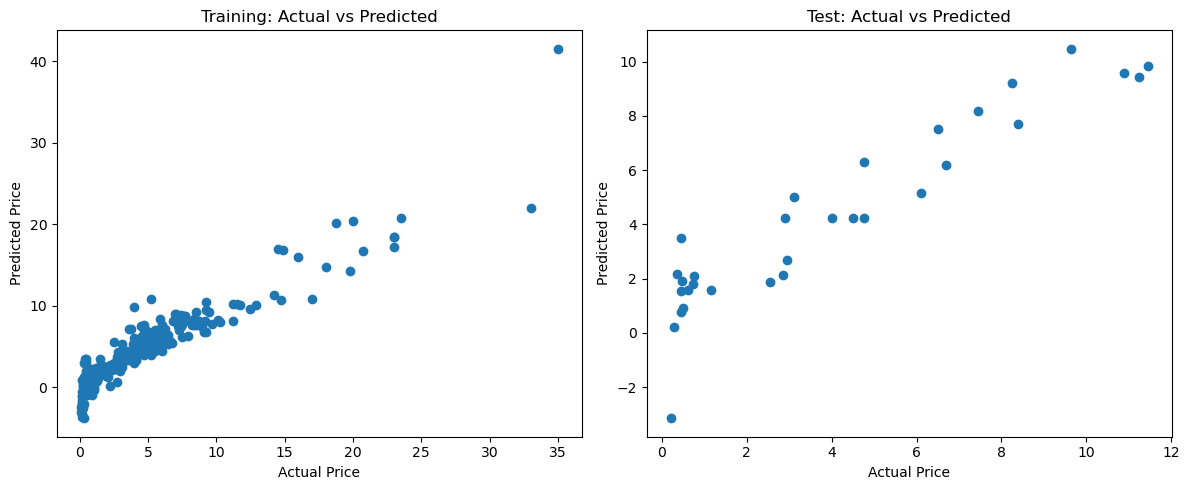

In [101]:
# Visualizing the Actual data and Predicted data from Linear Regression Model
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  
# Training data plot
axes[0].scatter(Y_train, training_pred)
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].set_title("Training: Actual vs Predicted")

# Test data plot
axes[1].scatter(Y_test, test_pred)
axes[1].set_xlabel("Actual Price")
axes[1].set_ylabel("Predicted Price")
axes[1].set_title("Test: Actual vs Predicted")  # fixed typo

plt.tight_layout()  # adjusts spacing
plt.show()

#### Using Lasso Regrerssion

In [102]:
lasso = Lasso()
lasso.fit(X_train, Y_train)

Lasso()

In [103]:
# Model evaluation
lasso_training_pred = lasso.predict(X_train)

In [104]:
# R-square for lasso - training data
error = metrics.r2_score(Y_train, lasso_training_pred)
print("R-Square Error for training data (Lasso): ", error)

R-Square Error for training data (Lasso):  0.8427856123435794


In [105]:
# For test data
lasso_test_pred = lasso.predict(X_test)
error = metrics.r2_score(Y_test, test_pred)
print("R-Square Error for test data (Lasso): ", error)

R-Square Error for test data (Lasso):  0.8693753727248014


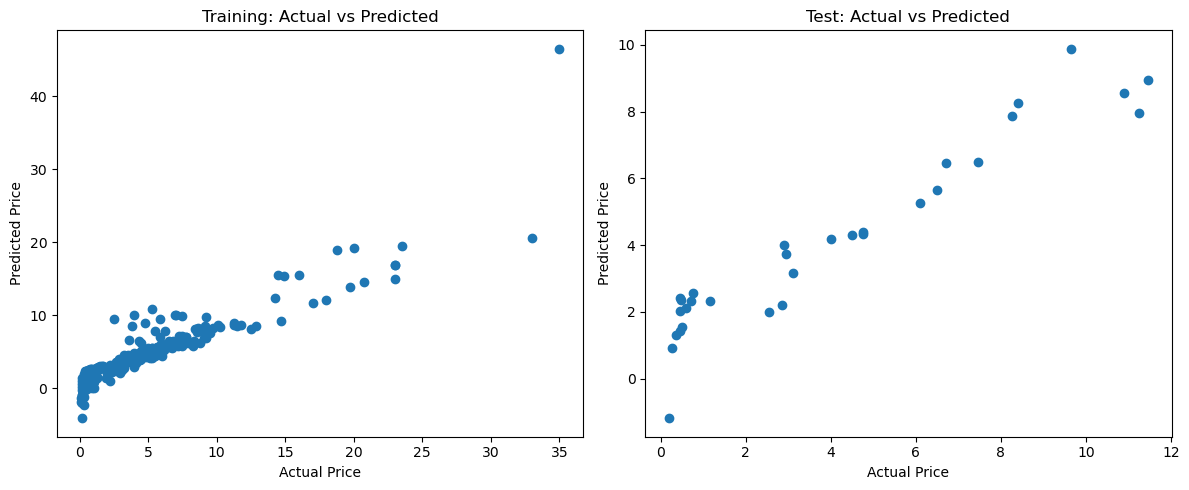

In [106]:
# Visualizing the Actual data and Predicted data from Lasso Regression Model
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 

# Training data plot
axes[0].scatter(Y_train, lasso_training_pred)
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].set_title("Training: Actual vs Predicted")

# Test data plot
axes[1].scatter(Y_test, lasso_test_pred)
axes[1].set_xlabel("Actual Price")
axes[1].set_ylabel("Predicted Price")
axes[1].set_title("Test: Actual vs Predicted")

plt.tight_layout()  # adjusts spacing
plt.show()